# Pré-processamento e Modelagem - Classificação de Diabetes

Este notebook implementa o pré-processamento dos dados e treina modelos de classificação.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
from sqlalchemy import create_engine
import os
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from botocore.client import Config

# Configurar MLFlow
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI', 'http://mlflow:5000'))
mlflow.set_experiment('diabetes_classification')

# Configurar boto3 e credenciais AWS para MLFlow salvar modelos no MinIO
try:
    # Configurar variáveis de ambiente para MLFlow
    os.environ['AWS_ACCESS_KEY_ID'] = os.getenv('AWS_ACCESS_KEY_ID', 'minioadmin')
    os.environ['AWS_SECRET_ACCESS_KEY'] = os.getenv('AWS_SECRET_ACCESS_KEY', 'minioadmin')
    os.environ['MLFLOW_S3_ENDPOINT_URL'] = os.getenv('MLFLOW_S3_ENDPOINT_URL', 'http://minio:9000')
    
    # Configurar cliente S3 para MinIO (para verificação)
    s3_endpoint = os.getenv('MLFLOW_S3_ENDPOINT_URL', 'http://minio:9000')
    s3_client = boto3.client(
        's3',
        endpoint_url=s3_endpoint,
        aws_access_key_id=os.environ['AWS_ACCESS_KEY_ID'],
        aws_secret_access_key=os.environ['AWS_SECRET_ACCESS_KEY'],
        config=Config(signature_version='s3v4'),
        region_name='us-east-1'
    )
    print("✅ Boto3 e credenciais AWS configuradas para MLFlow/MinIO")
    print(f"   Endpoint: {s3_endpoint}")
except Exception as e:
    print(f"⚠️ Aviso ao configurar boto3: {e}")
    print("   Continuando mesmo assim...")

# Conexão com PostgreSQL
POSTGRES_HOST = os.getenv('POSTGRES_HOST', 'postgres')
POSTGRES_PORT = os.getenv('POSTGRES_PORT', '5432')
POSTGRES_USER = os.getenv('POSTGRES_USER', 'postgres')
POSTGRES_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')
POSTGRES_DB = os.getenv('POSTGRES_DB', 'diabetes_db')

DATABASE_URL = f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"
engine = create_engine(DATABASE_URL)

# Carregar dados
query = "SELECT * FROM diabetes_processed"
df = pd.read_sql(query, engine)
print(f"Dataset carregado: {df.shape}")



✅ Boto3 e credenciais AWS configuradas para MLFlow/MinIO
   Endpoint: http://minio:9000
Dataset carregado: (3000, 16)


## Pré-processamento dos Dados


In [2]:
# Separar features e target
feature_cols = ['age', 'urea', 'creatinine', 'hba1c', 'cholesterol', 
                'triglycerides', 'hdl', 'ldl', 'vldl', 'bmi']

# Codificar gênero
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
feature_cols.append('gender_encoded')

# Preparar X e y
X = df[feature_cols].copy()
y = df['class_label'].copy()

# Codificar target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("=" * 60)
print("PRÉ-PROCESSAMENTO")
print("=" * 60)
print(f"\nFeatures selecionadas: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nDistribuição das classes:")
print(y.value_counts().sort_index())
print(f"\nMapeamento de classes:")
for i, label in enumerate(le_target.classes_):
    print(f"  {i}: {label}")


PRÉ-PROCESSAMENTO

Features selecionadas: 11
Features: ['age', 'urea', 'creatinine', 'hba1c', 'cholesterol', 'triglycerides', 'hdl', 'ldl', 'vldl', 'bmi', 'gender_encoded']

Shape de X: (3000, 11)
Shape de y: (3000,)

Distribuição das classes:
class_label
N     309
P     159
Y    2532
Name: count, dtype: int64

Mapeamento de classes:
  0: N
  1: P
  2: Y


In [3]:
# Verificar valores faltantes e outliers
print("=" * 60)
print("VERIFICAÇÃO DE QUALIDADE DOS DADOS")
print("=" * 60)

print("\nValores faltantes:")
missing = X.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Nenhum valor faltante encontrado!")

# Detectar outliers usando IQR
print("\nOutliers detectados (usando IQR):")
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).sum()
print(outliers[outliers > 0] if outliers.sum() > 0 else "Nenhum outlier significativo detectado")

# Estatísticas básicas
print("\nEstatísticas descritivas das features:")
print(X.describe())


VERIFICAÇÃO DE QUALIDADE DOS DADOS

Valores faltantes:
Nenhum valor faltante encontrado!

Outliers detectados (usando IQR):
age              294
urea             195
creatinine       156
hba1c             18
cholesterol       81
triglycerides    165
hdl              150
ldl               33
vldl             222
bmi                9
dtype: int64

Estatísticas descritivas das features:
               age         urea   creatinine        hba1c  cholesterol  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean     53.528000     5.124743    68.943000     8.281160     4.862820   
std       8.796306     2.934187    59.964742     2.533158     1.301303   
min      20.000000     0.500000     6.000000     0.900000     0.000000   
25%      51.000000     3.700000    48.000000     6.500000     4.000000   
50%      55.000000     4.600000    60.000000     8.000000     4.800000   
75%      59.000000     5.700000    73.000000    10.200000     5.600000   
max      79.000000   

In [4]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("=" * 60)
print("DIVISÃO TREINO/TESTE")
print("=" * 60)
print(f"\nTreino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição de classes no treino:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nDistribuição de classes no teste:")
print(pd.Series(y_test).value_counts().sort_index())


DIVISÃO TREINO/TESTE

Treino: 2400 amostras
Teste: 600 amostras

Distribuição de classes no treino:
0     247
1     127
2    2026
Name: count, dtype: int64

Distribuição de classes no teste:
0     62
1     32
2    506
Name: count, dtype: int64


In [5]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("NORMALIZAÇÃO")
print("=" * 60)
print("Features normalizadas usando StandardScaler")
print(f"Shape treino normalizado: {X_train_scaled.shape}")
print(f"Shape teste normalizado: {X_test_scaled.shape}")


NORMALIZAÇÃO
Features normalizadas usando StandardScaler
Shape treino normalizado: (2400, 11)
Shape teste normalizado: (600, 11)


In [6]:
# Balancear dados usando SMOTE
print("=" * 60)
print("BALANCEAMENTO COM SMOTE")
print("=" * 60)

print(f"\nAntes do balanceamento:")
print(f"Distribuição de classes no treino: {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nApós balanceamento:")
print(f"Distribuição de classes no treino: {np.bincount(y_train_balanced)}")
print(f"Shape do treino balanceado: {X_train_balanced.shape}")


BALANCEAMENTO COM SMOTE

Antes do balanceamento:
Distribuição de classes no treino: [ 247  127 2026]

Após balanceamento:
Distribuição de classes no treino: [2026 2026 2026]
Shape do treino balanceado: (6078, 11)


## Treinamento de Modelos


## Validação Cruzada (Opcional)


In [7]:
# Validação cruzada no melhor modelo (opcional, mas recomendado)
from sklearn.model_selection import cross_val_score

if results:
    best_model_name = results_df.iloc[0]['Model']
    best_model = results[best_model_name]['model']
    
    print("=" * 60)
    print(f"VALIDAÇÃO CRUZADA - {best_model_name}")
    print("=" * 60)
    
    # Validação cruzada com 5 folds
    cv_scores = cross_val_score(best_model, X_train_balanced, y_train_balanced, 
                                cv=5, scoring='f1_weighted', n_jobs=-1)
    
    print(f"\nScores de validação cruzada (5-fold):")
    print(f"  Fold 1: {cv_scores[0]:.4f}")
    print(f"  Fold 2: {cv_scores[1]:.4f}")
    print(f"  Fold 3: {cv_scores[2]:.4f}")
    print(f"  Fold 4: {cv_scores[3]:.4f}")
    print(f"  Fold 5: {cv_scores[4]:.4f}")
    print(f"\nMédia: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Log no MLFlow
    with mlflow.start_run(run_name=f"{best_model_name} - CV"):
        mlflow.log_metric("cv_mean", cv_scores.mean())
        mlflow.log_metric("cv_std", cv_scores.std())
        mlflow.log_metric("cv_min", cv_scores.min())
        mlflow.log_metric("cv_max", cv_scores.max())
    
    print("\n✅ Validação cruzada concluída e registrada no MLFlow")


NameError: name 'results' is not defined

In [8]:
# Definir modelos para testar
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, probability=True, kernel='rbf'),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

print("=" * 60)
print("MODELOS A SEREM TREINADOS")
print("=" * 60)
for name in models.keys():
    print(f"  - {name}")

results = {}


MODELOS A SEREM TREINADOS
  - Random Forest
  - Gradient Boosting
  - SVM
  - Logistic Regression
  - KNN


In [9]:
# Salvar métricas no banco de dados para o dashboard
from sqlalchemy import text

print("\n" + "=" * 60)
print("SALVANDO MÉTRICAS NO BANCO DE DADOS")
print("=" * 60)

# Limpar métricas antigas
with engine.connect() as conn:
    conn.execute(text("DELETE FROM model_metrics"))
    conn.commit()

# Inserir métricas de cada modelo
for name, result in results.items():
    report = classification_report(y_test, result['predictions'], 
                                  target_names=le_target.classes_, 
                                  output_dict=True, zero_division=0)
    
    metrics_data = {
        'model_name': name,
        'accuracy': float(result['accuracy']),
        'f1_score_weighted': float(result['f1_score']),
        'f1_score_macro': float(result['f1_macro']),
        'precision_n': float(report.get('N', {}).get('precision', 0.0)),
        'precision_p': float(report.get('P', {}).get('precision', 0.0)),
        'precision_y': float(report.get('Y', {}).get('precision', 0.0)),
        'recall_n': float(report.get('N', {}).get('recall', 0.0)),
        'recall_p': float(report.get('P', {}).get('recall', 0.0)),
        'recall_y': float(report.get('Y', {}).get('recall', 0.0)),
        'mlflow_run_id': 'pending'  # Será atualizado pelo notebook de exportação
    }
    
    with engine.connect() as conn:
        conn.execute(text("""
            INSERT INTO model_metrics 
            (model_name, accuracy, f1_score_weighted, f1_score_macro,
             precision_n, precision_p, precision_y,
             recall_n, recall_p, recall_y, mlflow_run_id)
            VALUES (:model_name, :accuracy, :f1_score_weighted, :f1_score_macro,
                    :precision_n, :precision_p, :precision_y,
                    :recall_n, :recall_p, :recall_y, :mlflow_run_id)
        """), metrics_data)
        conn.commit()
    
    print(f"✅ Métricas de {name} salvas no banco")

print("\n✅ Todas as métricas foram salvas no banco de dados!")
print("Execute o notebook 04_export_to_dashboard.ipynb para atualizar com dados do MLFlow")



SALVANDO MÉTRICAS NO BANCO DE DADOS

✅ Todas as métricas foram salvas no banco de dados!
Execute o notebook 04_export_to_dashboard.ipynb para atualizar com dados do MLFlow


In [11]:
# Treinar e avaliar cada modelo
print("=" * 60)
print("TREINAMENTO E AVALIAÇÃO DOS MODELOS")
print("=" * 60)

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Treinando: {name}")
    print(f"{'='*60}")
    
    try:
        with mlflow.start_run(run_name=name):
            # Treinar modelo
            model.fit(X_train_balanced, y_train_balanced)
            
            # Predições
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)
            
            # Métricas
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_macro = f1_score(y_test, y_pred, average='macro')
            
            # Log no MLFlow
            mlflow.log_param("model", name)
            mlflow.log_param("n_features", X_train.shape[1])
            mlflow.log_param("n_train_samples", len(X_train_balanced))
            mlflow.log_param("n_test_samples", len(X_test))
            mlflow.log_metric("accuracy", accuracy)
            mlflow.log_metric("f1_score_weighted", f1)
            mlflow.log_metric("f1_score_macro", f1_macro)
            
            # Log métricas por classe
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            for class_idx, class_name in enumerate(le_target.classes_):
                if str(class_idx) in report:
                    mlflow.log_metric(f"precision_{class_name}", report[str(class_idx)]['precision'])
                    mlflow.log_metric(f"recall_{class_name}", report[str(class_idx)]['recall'])
                    mlflow.log_metric(f"f1_{class_name}", report[str(class_idx)]['f1-score'])
            
            # Salvar modelo
            mlflow.sklearn.log_model(model, "model")
            
            # Salvar scaler
            mlflow.sklearn.log_model(scaler, "scaler")
            
            results[name] = {
                'accuracy': accuracy,
                'f1_score': f1,
                'f1_macro': f1_macro,
                'model': model,
                'predictions': y_pred,
                'predictions_proba': y_pred_proba
            }
            
            print(f"✅ Accuracy: {accuracy:.4f}")
            print(f"✅ F1-Score (weighted): {f1:.4f}")
            print(f"✅ F1-Score (macro): {f1_macro:.4f}")
            print(f"\nClassification Report:")
            print(classification_report(y_test, y_pred, target_names=le_target.classes_))
            
    except Exception as e:
        print(f"❌ Erro ao treinar {name}: {str(e)}")
        continue

print(f"\n{'='*60}")
print("TREINAMENTO CONCLUÍDO")
print(f"{'='*60}")


TREINAMENTO E AVALIAÇÃO DOS MODELOS

Treinando: Random Forest


/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2025/11/24 18:45:15 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


✅ Accuracy: 1.0000
✅ F1-Score (weighted): 1.0000
✅ F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        62
           P       1.00      1.00      1.00        32
           Y       1.00      1.00      1.00       506

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Treinando: Gradient Boosting


/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2025/11/24 18:45:21 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


✅ Accuracy: 1.0000
✅ F1-Score (weighted): 1.0000
✅ F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        62
           P       1.00      1.00      1.00        32
           Y       1.00      1.00      1.00       506

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Treinando: SVM


...

✅ Accuracy: 0.9817
✅ F1-Score (weighted): 0.9821
✅ F1-Score (macro): 0.9496

Classification Report:
              precision    recall  f1-score   support

           N       0.91      0.95      0.93        62
           P       0.86      1.00      0.93        32
           Y       1.00      0.98      0.99       506

    accuracy                           0.98       600
   macro avg       0.92      0.98      0.95       600
weighted avg       0.98      0.98      0.98       600


Treinando: Logistic Regression


/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2025/11/24 18:45:28 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


✅ Accuracy: 0.9267
✅ F1-Score (weighted): 0.9332
✅ F1-Score (macro): 0.8057

Classification Report:
              precision    recall  f1-score   support

           N       0.78      0.85      0.82        62
           P       0.51      0.84      0.64        32
           Y       0.99      0.94      0.97       506

    accuracy                           0.93       600
   macro avg       0.76      0.88      0.81       600
weighted avg       0.95      0.93      0.93       600


Treinando: KNN


/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2025/11/24 18:45:32 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


✅ Accuracy: 0.9750
✅ F1-Score (weighted): 0.9758
✅ F1-Score (macro): 0.9419

Classification Report:
              precision    recall  f1-score   support

           N       0.89      1.00      0.94        62
           P       0.82      1.00      0.90        32
           Y       1.00      0.97      0.98       506

    accuracy                           0.97       600
   macro avg       0.90      0.99      0.94       600
weighted avg       0.98      0.97      0.98       600


TREINAMENTO CONCLUÍDO


## Comparação de Modelos


COMPARAÇÃO DE MODELOS
              Model  Accuracy  F1-Score (weighted)  F1-Score (macro)
      Random Forest  1.000000             1.000000          1.000000
  Gradient Boosting  1.000000             1.000000          1.000000
                SVM  0.981667             0.982093          0.949567
                KNN  0.975000             0.975791          0.941919
Logistic Regression  0.926667             0.933218          0.805725


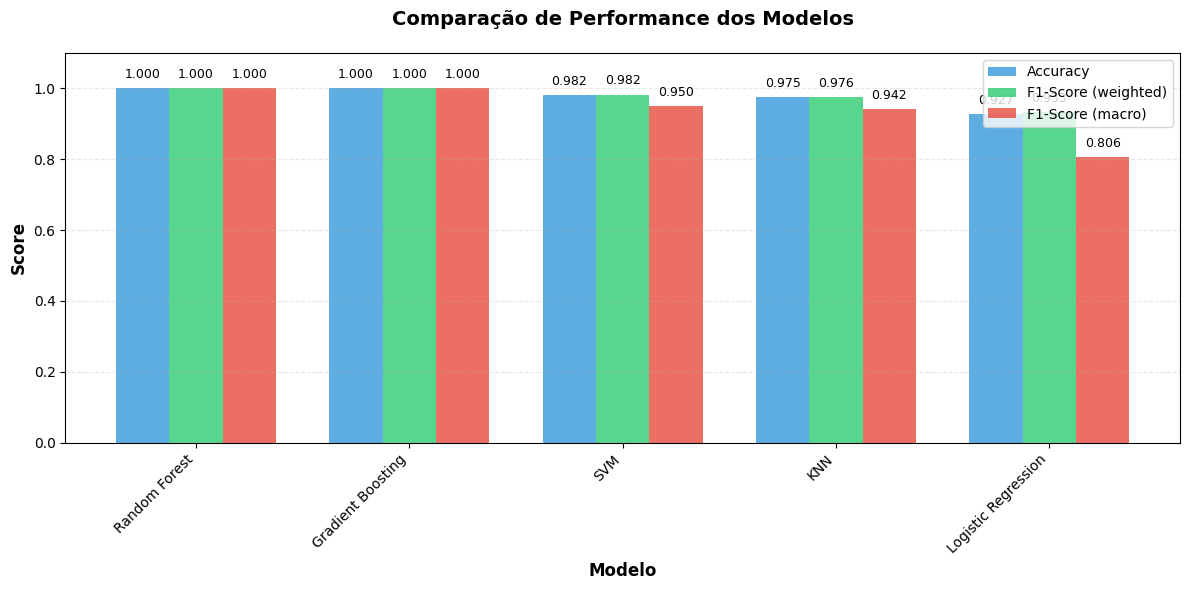

In [12]:
# Comparar resultados
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [r['accuracy'] for r in results.values()],
        'F1-Score (weighted)': [r['f1_score'] for r in results.values()],
        'F1-Score (macro)': [r['f1_macro'] for r in results.values()]
    }).sort_values('Accuracy', ascending=False)
    
    print("=" * 60)
    print("COMPARAÇÃO DE MODELOS")
    print("=" * 60)
    print(results_df.to_string(index=False))
    
    # Visualização
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(results_df))
    width = 0.25
    
    ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
    ax.bar(x, results_df['F1-Score (weighted)'], width, label='F1-Score (weighted)', color='#2ecc71', alpha=0.8)
    ax.bar(x + width, results_df['F1-Score (macro)'], width, label='F1-Score (macro)', color='#e74c3c', alpha=0.8)
    
    ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Comparação de Performance dos Modelos', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])
    
    # Adicionar valores nas barras
    for i, (acc, f1_w, f1_m) in enumerate(zip(results_df['Accuracy'], 
                                                results_df['F1-Score (weighted)'],
                                                results_df['F1-Score (macro)'])):
        ax.text(i - width, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i, f1_w + 0.02, f'{f1_w:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width, f1_m + 0.02, f'{f1_m:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../reports/model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Nenhum modelo foi treinado com sucesso!")


## Análise do Melhor Modelo


MELHOR MODELO: Random Forest
Accuracy: 1.0000
F1-Score (weighted): 1.0000
F1-Score (macro): 1.0000


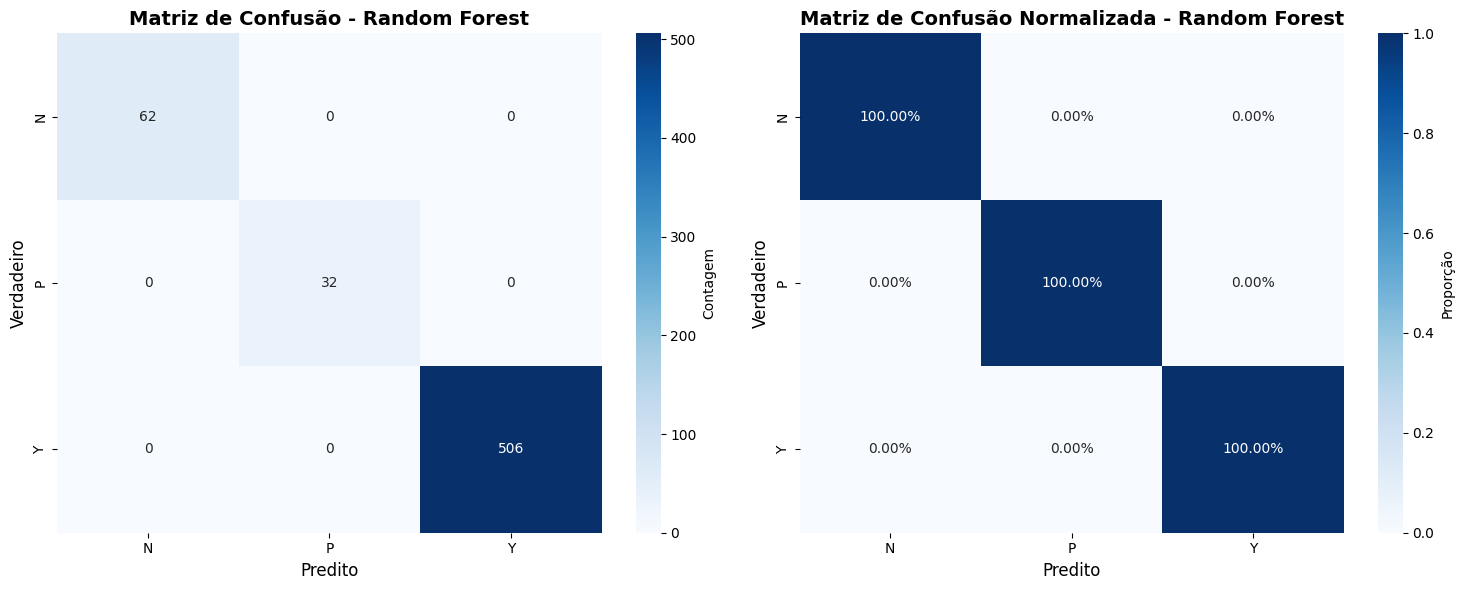


RELATÓRIO DETALHADO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        62
           P       1.00      1.00      1.00        32
           Y       1.00      1.00      1.00       506

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


IMPORTÂNCIA DAS FEATURES
       feature  importance
         hba1c    0.501241
           bmi    0.190668
           age    0.153917
   cholesterol    0.031080
 triglycerides    0.028625
          vldl    0.025434
          urea    0.019044
           ldl    0.016750
    creatinine    0.013408
           hdl    0.012117
gender_encoded    0.007716


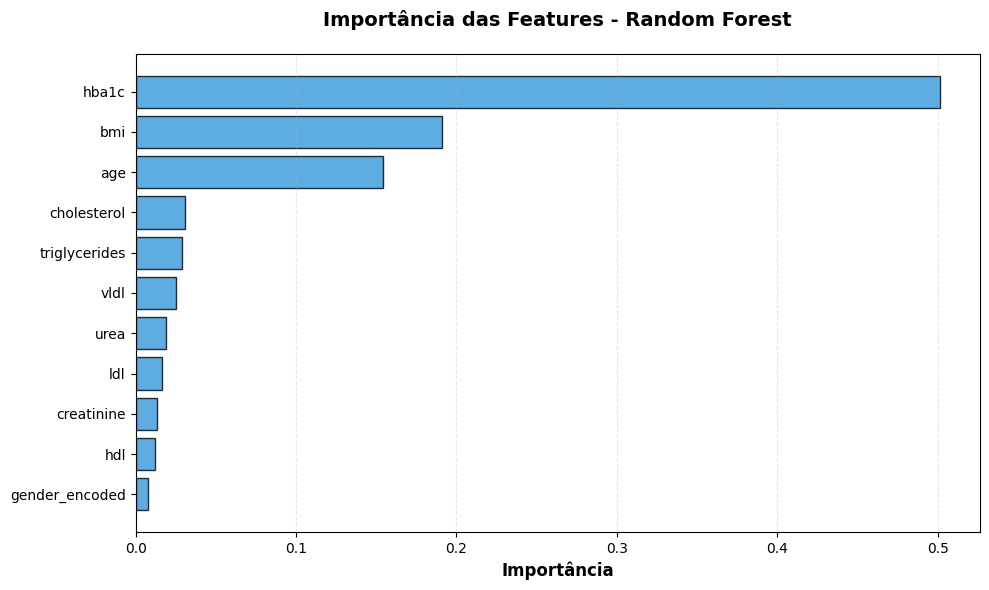

In [13]:
# Identificar melhor modelo
if results:
    best_model_name = results_df.iloc[0]['Model']
    best_model = results[best_model_name]['model']
    best_predictions = results[best_model_name]['predictions']
    
    print("=" * 60)
    print(f"MELHOR MODELO: {best_model_name}")
    print("=" * 60)
    print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")
    print(f"F1-Score (weighted): {results[best_model_name]['f1_score']:.4f}")
    print(f"F1-Score (macro): {results[best_model_name]['f1_macro']:.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, best_predictions)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Matriz de confusão numérica
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=le_target.classes_, yticklabels=le_target.classes_,
                cbar_kws={'label': 'Contagem'})
    axes[0].set_title(f'Matriz de Confusão - {best_model_name}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Verdadeiro', fontsize=12)
    axes[0].set_xlabel('Predito', fontsize=12)
    
    # Matriz de confusão normalizada
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=le_target.classes_, yticklabels=le_target.classes_,
                cbar_kws={'label': 'Proporção'})
    axes[1].set_title(f'Matriz de Confusão Normalizada - {best_model_name}', 
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Verdadeiro', fontsize=12)
    axes[1].set_xlabel('Predito', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('../reports/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Classification report detalhado
    print("\n" + "=" * 60)
    print("RELATÓRIO DETALHADO DE CLASSIFICAÇÃO")
    print("=" * 60)
    print(classification_report(y_test, best_predictions, target_names=le_target.classes_))
    
    # Feature importance (se disponível)
    if hasattr(best_model, 'feature_importances_'):
        print("\n" + "=" * 60)
        print("IMPORTÂNCIA DAS FEATURES")
        print("=" * 60)
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(feature_importance.to_string(index=False))
        
        # Visualizar importância
        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance['feature'], feature_importance['importance'], 
                color='#3498db', alpha=0.8, edgecolor='black')
        plt.xlabel('Importância', fontsize=12, fontweight='bold')
        plt.title(f'Importância das Features - {best_model_name}', 
                 fontsize=14, fontweight='bold', pad=20)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Nenhum modelo disponível para análise!")


## Conclusões e Próximos Passos

### Resultados Obtidos:

1. **Melhor Modelo**: [Será preenchido após execução]
2. **Accuracy**: [Será preenchido após execução]
3. **F1-Score**: [Será preenchido após execução]

### Melhorias Futuras:

1. **Ajuste de Hiperparâmetros**: Usar GridSearchCV ou RandomizedSearchCV
2. **Feature Engineering**: Criar novas features ou selecionar as mais importantes
3. **Ensemble Methods**: Combinar múltiplos modelos
4. **Validação Cruzada**: Avaliar modelos com k-fold cross-validation
5. **Análise de Erros**: Investigar casos onde o modelo erra

### Visualização no MLFlow:

Acesse http://localhost:5000 para ver:
- Todos os experimentos registrados
- Comparação de métricas entre modelos
- Modelos versionados e salvos
- Parâmetros de cada execução
